In [6]:
import pandas as pd
from pymatgen.core import Structure
import json
from ast import literal_eval

In [2]:
data = pd.read_csv("MiAD-1.csv.gz", index_col="material_id")

In [8]:
structures = data.structure.apply(literal_eval).apply(Structure.from_dict)

In [28]:
generated_len = structures.apply(len)

In [19]:
mp_20 = pd.read_csv("~/WyckoffTransformer/cdvae/data/mp_20/train.csv", index_col="material_id")

In [26]:
from functools import partial
cif_parser = partial(Structure.from_str, fmt="cif")
mp_20_structs = mp_20.cif.apply(cif_parser)

/home/kna/.conda/envs/nscc-vasp-computer/lib/python3.13/site-packages/pymatgen/io/cif.py:1290: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/kna/.conda/envs/nscc-vasp-computer/lib/python3.13/site-packages/pymatgen/io/cif.py:1290: UserWarning: Issues encountered while parsing CIF: 12 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/kna/.conda/envs/nscc-vasp-computer/lib/python3.13/site-packages/pymatgen/io/cif.py:1290: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
/home/kna/.conda/envs/nscc-vasp-computer/l

In [29]:
mp_20_len = mp_20_structs.apply(len)

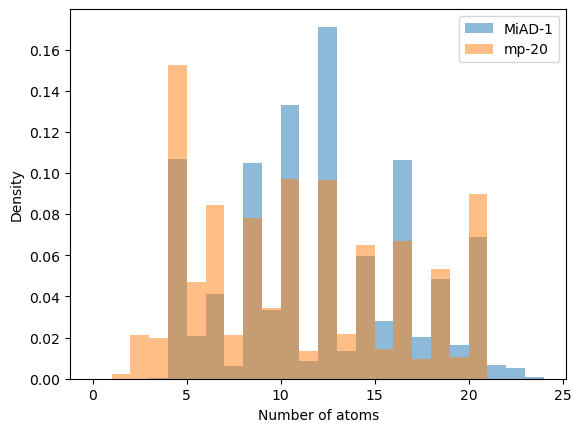

In [35]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
import numpy as np
bins = np.arange(0, 25)
ax.hist(generated_len, bins=bins, alpha=0.5, label="MiAD-1", density=True);
ax.hist(mp_20_len, bins=bins, alpha=0.5, label="mp-20", density=True)
ax.set_xlabel("Number of atoms")
ax.set_ylabel("Density")
ax.legend();